# Signal shape — performance signals (X)

*Read-only informative artifact. Characterises each candidate signal so a
human can decide which carry usable information. No gate decisions, no
PROCEED/STOP verdict.*

## Questions this notebook answers

- **Does this signal fire at this position?** A goalkeeper has no `xg`; a
  forward's `saves` is always zero. Structural absence by football logic.
- **Does it move, or is it flat?** Near-zero variance means the signal is dead
  regardless of who is playing — it can't tell players apart.
- **What kind of signal is it?** Event-driven (rare spikes around goal events)
  or continuous (accumulates through general involvement)?

Everything below is **season-pooled** over the whole season. How signals
evolve week-to-week is deferred to the `temporal/` layer.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and the **participation** population (`minutes > 0`), build position
cohorts, and identify the candidate signal columns.

This is a *descriptive characterisation* notebook, so it uses the full season —
no early-GW lower bound (that GW-6 cut in the older EDA-1 record was a
*predictive-evaluation* choice, not relevant here).

The population is everyone who **actually featured**: available players with
`minutes > 0`. This is a **participation** filter (the player appeared), **not
a performance gate**. `minutes` can be NULL for some rows; `minutes > 0`
naturally excludes those. The 60-minute performance-boundary question is
**deferred to the `population/` layer** — the layer meant to study and justify
that boundary — and is deliberately not baked in here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]
cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

# Player action signals only. Excludes:
#   identity/grain/market/structural/target — non-signal mart columns
#   rolling/derived features              — _rollN, _trend suffixes
#   fixture/context level                 — fdr_avg, xgc, home_count, away_count, fixture_count
#   status flags                          — is_live, is_next, is_previous, finished
#   manager/market behaviour              — transfers_in, transfers_out, ownership_count
# xgc excluded: team/fixture context (minutes-weighted opposition xg), not a player action;
# FWD earn 0 clean sheet points so xgc carries no FPL relevance for them at all.
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
}
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)
print("\nSignals:", SIGNALS)


Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412

Signals: ['assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'own_goals', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'saves', 'starts', 'tackles', 'threat', 'xa', 'xg', 'xgi', 'yellow_cards']


## DGW prevalence — magnitude of the fixture-doubling confound

*How much of the featured population is double-gameweek?*

**What we measure** — share of featured player-gameweeks (`minutes > 0`) that are double-gameweeks (`is_dgw == True`), by position.

**What it means** — most signals here are additive per fixture, so a DGW row roughly doubles them. This sizes what fraction of the rows feeding each distribution carry two fixtures' worth of output.

**What it doesn't mean** — description of prevalence only; no normalisation or exclusion. Per-fixture treatment is deferred to the `fixture/` layer.

In [2]:
# DGW prevalence by position (descriptive only -- no normalisation, no exclusion).
_dgw = df.groupby("position")["is_dgw"].agg(n="count", dgw_rows="sum").reset_index()
_all = pd.DataFrame([{"position": "ALL", "n": len(df), "dgw_rows": int(df["is_dgw"].sum())}])
dgw_prevalence = (
    pd.concat([_dgw, _all], ignore_index=True)
    .assign(**{"dgw_%": lambda d: (d["dgw_rows"] / d["n"] * 100).round(2)})
)
display(dgw_prevalence)


,position,n,dgw_rows,dgw_%
0,DEF,3904,59,1.510
1,FWD,1412,22,1.560
2,GK,757,10,1.320
3,MID,5288,80,1.510
4,ALL,11361,171,1.510


## (a) Distribution, variance and zero-mass by position, per signal

*For each signal at each position, does it fire, does it move, and what kind of signal is it?*

**What we measure** — for every (signal, position) pair: variance, skew, and zero-mass fraction (share of rows == 0).

Three questions hold at the signal level with pooled season data:

- **zero-mass** — *Does it fire at this position?* Near-total zero-mass means the signal is structurally absent (GK xg, FWD saves).
- **variance / IQR** — *Is it flat or does it move?* Near-zero variance means the signal doesn't vary at all — dead regardless of who's playing.
- **skew + zero-mass together** — *What's its character?* High zero-mass with high positive skew = event-driven (rare spikes around goal events). Low zero-mass with moderate skew = continuous (accumulates through general involvement regardless of specific events).

**What it doesn't mean** — absolute signal levels (mean, p90) are not interpretable here; they only gain meaning relative to Y or to another player, both out of scope for this layer. Variance says the signal moves; it does not say why or in whose games.

In [3]:
rows = []
for sig in SIGNALS:
    for pos in POSITIONS:
        s = cohorts[pos][sig].dropna().astype(float)
        st = compute_distribution_stats(s)
        rows.append({
            "signal": sig,
            "position": pos,
            "n": int(st["count"]) if not np.isnan(st["count"]) else 0,
            "variance": st["variance"],
            "skew": st["skew"],
            "zero_mass_%": round((s == 0).mean() * 100, 1) if len(s) else np.nan,
        })
signal_profile = pd.DataFrame(rows)
display(signal_profile[["signal", "position", "n", "variance", "zero_mass_%"]].round(3))


,signal,position,n,variance,zero_mass_%
0,assists,GK,757,0.007,99.300
1,assists,DEF,3904,0.060,94.100
2,assists,MID,5288,0.115,89.500
3,assists,FWD,1412,0.083,93.000
4,bonus,GK,757,0.438,88.900
...,...,...,...,...,...
91,xgi,FWD,1412,0.137,19.200
92,yellow_cards,GK,757,0.067,92.700
93,yellow_cards,DEF,3904,0.126,85.300
94,yellow_cards,MID,5288,0.110,87.400


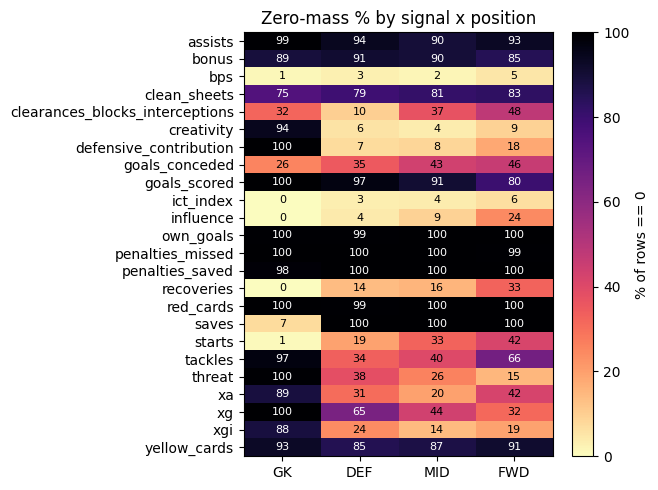

In [4]:
# A heatmap reveals shape the long table hides: which signal/position cells
# are dead (high zero-mass) at a glance.
pivot = signal_profile.pivot(index="signal", columns="position", values="zero_mass_%")
pivot = pivot[POSITIONS]
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(pivot.values, cmap="magma_r", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(POSITIONS)))
ax.set_xticklabels(POSITIONS)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 50 else "black", fontsize=8)
ax.set_title("Zero-mass % by signal x position")
fig.colorbar(im, ax=ax, label="% of rows == 0")
plt.tight_layout()
plt.show()


## (b) Degenerate-signal flag

*Which signal/position pairs are structurally absent and should be set aside?*

**What we measure** — a flag on each (signal, position) pair using two heuristics:
- `near_zero_variance` — variance < 2e-4 (effectively a zero-check; raised from 1e-4 to ensure algebraic composites are caught when all components are degenerate — `xgi GK` would slip through at 1e-4 even though both `xg GK` and `xa GK` are degenerate)
- `high_zero_mass` — zero-mass ≥ 93% (data-calibrated: above this the zero-mass distribution shows structural football absence — GK never scores, DEF never saves; below 93% signals fire occasionally and calling them degenerate is harder to defend)

A pair is flagged `degenerate` if either holds.

**What it means** — flagged pairs carry little usable information at that position and are candidates to drop from position-specific analysis. Directs attention; not a verdict.

**What it doesn't mean** — a rare-but-decisive signal (fires 5% of weeks but those weeks haul) would be flagged yet still matter; the flag does not test association with `total_points`.

In [5]:
NEAR_ZERO_VARIANCE = 2e-4   # catches xg/xa/xgi GK (all components degenerate → composite too)
HIGH_ZERO_MASS_PCT = 93.0    # data-calibrated: above this = structural absence by football logic

flagged = signal_profile.copy()
flagged["near_zero_variance"] = flagged["variance"] < NEAR_ZERO_VARIANCE
flagged["high_zero_mass"] = flagged["zero_mass_%"] >= HIGH_ZERO_MASS_PCT
flagged["degenerate"] = flagged["near_zero_variance"] | flagged["high_zero_mass"]

print(f"Heuristics: variance < {NEAR_ZERO_VARIANCE:g}  OR  zero_mass >= {HIGH_ZERO_MASS_PCT}%")
print(f"Flagged degenerate: {int(flagged['degenerate'].sum())} of {len(flagged)} (signal, position) pairs\n")
display(
    flagged.loc[
        flagged["degenerate"],
        ["signal", "position", "variance", "zero_mass_%", "near_zero_variance", "high_zero_mass"],
    ].reset_index(drop=True)
)


Heuristics: variance < 0.0002  OR  zero_mass >= 93.0%
Flagged degenerate: 31 of 96 (signal, position) pairs



,signal,position,variance,zero_mass_%,near_zero_variance,high_zero_mass
0,assists,GK,0.007,99.300,False,True
1,assists,DEF,0.060,94.100,False,True
2,assists,FWD,0.083,93.000,False,True
3,creativity,GK,4.497,94.200,False,True
4,defensive_contribution,GK,0.000,100.000,True,True
5,goals_scored,GK,0.000,100.000,True,True
6,goals_scored,DEF,0.038,96.700,False,True
7,own_goals,GK,0.005,99.500,False,True
8,own_goals,DEF,0.008,99.300,False,True
9,own_goals,MID,0.001,99.900,False,True


## (c) Signal character — skew of remaining signals

*For the signals that survive the degenerate filter, are they event-driven or continuous?*

**What we measure** — skew of the non-degenerate signal/position pairs only.

**What it means** — high skew = event-driven (fires rarely, spikes when it does — goals, assists, xg). Low/moderate skew = continuous (accumulates through general involvement — ICT, BPS, influence). Read alongside zero-mass: both high zero-mass and high skew together confirm event-driven character.

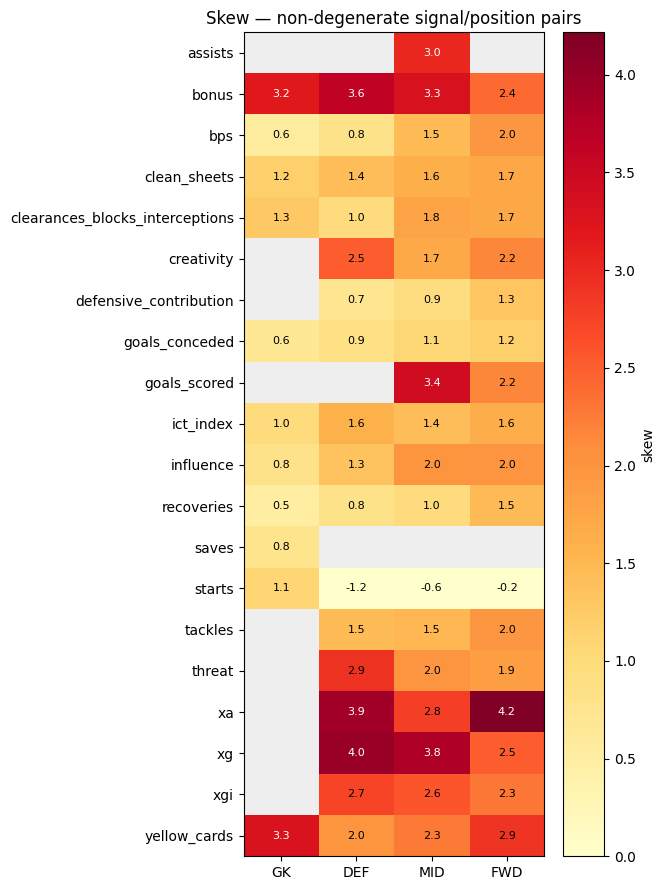

In [6]:
alive = flagged[~flagged["degenerate"]].copy()
pivot = alive.pivot(index="signal", columns="position", values="skew").reindex(columns=POSITIONS)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#eeeeee")

data = pivot.values.astype(float)
masked = np.ma.masked_invalid(data)

fig, ax = plt.subplots(figsize=(6.5, max(4, len(pivot) * 0.45)))
im = ax.imshow(masked, cmap=cmap, aspect="auto", vmin=0)
ax.set_xticks(range(len(POSITIONS)))
ax.set_xticklabels(POSITIONS)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                    color="white" if v > 3 else "black", fontsize=8)
ax.set_title("Skew — non-degenerate signal/position pairs")
fig.colorbar(im, ax=ax, label="skew")
plt.tight_layout()
plt.show()


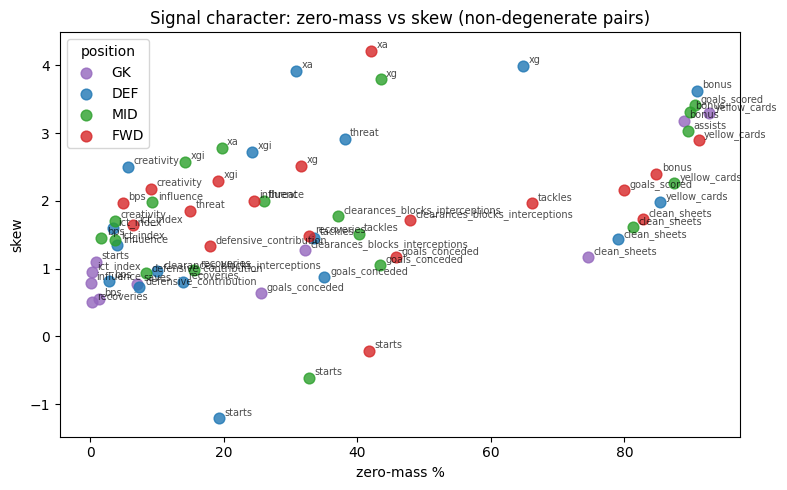

In [7]:
# Scatter: zero-mass vs skew for alive pairs — event-driven cluster vs continuous cluster.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}

fig, ax = plt.subplots(figsize=(8, 5))
for pos in POSITIONS:
    subset = alive[alive["position"] == pos]
    ax.scatter(subset["zero_mass_%"], subset["skew"],
               color=colours[pos], label=pos, s=60, alpha=0.8)
    for _, row in subset.iterrows():
        ax.annotate(row["signal"], (row["zero_mass_%"], row["skew"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points", alpha=0.7)

ax.set_xlabel("zero-mass %")
ax.set_ylabel("skew")
ax.set_title("Signal character: zero-mass vs skew (non-degenerate pairs)")
ax.legend(title="position")
plt.tight_layout()
plt.show()


## What the signals look like

Plain-language summary (not a verdict):

- **Structural absence follows football logic** — attacking signals (`xg`, `xa`, `xgi`,
  `threat`, `creativity`, `goals_scored`) are degenerate for GK and DEF; defensive event
  signals (`saves`, `penalties_saved`) are degenerate for outfielders. The degenerate flag
  concentrates exactly where the sport predicts.
- **The DC mart signals add three absence patterns** — `defensive_contribution` is
  fully degenerate at GK (zero at every GW: the 2025/26 DC rule does not apply to GK,
  so the field is structurally 0 by rule design). `tackles` is near-degenerate at GK
  (97% zero-mass). `own_goals` and `penalties_missed` are near-degenerate at all
  positions (99%+ zero-mass): not structural football absence but extreme rarity —
  they fire in fewer than 1% of appearances. They remain in the signal set because they
  enter the FPL scoring model, but they carry no discriminative signal in practice.
- **Alive signals split by character** — goal-event signals (`xg`, `xa`, `xgi`,
  `goals_scored`, `assists`, `clean_sheets`) are event-driven: high zero-mass and high
  skew. Composite signals (`ict_index`, `bps`, `influence`, `creativity`) are continuous:
  low zero-mass and moderate skew, accumulating through general match involvement.
  Defensive action signals (`clearances_blocks_interceptions`, `recoveries`, `tackles` at
  DEF/MID; `defensive_contribution` at DEF/MID/FWD) sit between these: low-moderate
  zero-mass and low-moderate skew. `recoveries` is the most continuous (GK zero-mass
  only 0.3%, skew 0.50 — the most symmetric signal in the set). `defensive_contribution`
  is similarly continuous at DEF/MID (zero-mass 7–8%, skew 0.74–0.93), tracking
  general defensive involvement rather than discrete events.

All **whole-season**, season-pooled, over the **participation** population
(`minutes > 0`). Within-player signal behaviour is deferred to the `temporal/` layer.